# MNIST-Model-Benchmark

Este notebook apresenta o desenvolvimento do MNIST Model Benchmark, utilizando o dataset MNIST, composto por imagens em escala de cinza de dígitos manuscritos de 0 a 9. 
O projeto contempla análise exploratória, preparação dos dados, treinamento, avaliação e comparação de modelos de classificação.

## Configuração do ambiente

Nesta etapa, o notebook identifica a raiz do projeto e configura o caminho necessário para acessar os módulos desenvolvidos na pasta `src`.

In [1]:
import sys  # Permite adicionar a raiz do projeto ao caminho de importação do Python
from pathlib import Path  # Permite manipular caminhos de arquivos e diretórios de forma independente do sistema operacional

RAIZ_PROJETO = Path.cwd()  # Obtém o diretório atual de execução do notebook

while not (RAIZ_PROJETO / "src").exists():  # Procura a raiz do projeto até encontrar a pasta src
    RAIZ_PROJETO = RAIZ_PROJETO.parent  # Sobe um nível na estrutura de diretórios

if str(RAIZ_PROJETO) not in sys.path:  # Verifica se a raiz ainda não está disponível para importação
    sys.path.append(str(RAIZ_PROJETO))  # Adiciona a raiz para permitir imports dos módulos da pasta src

print("Raiz do projeto:", RAIZ_PROJETO)  # Exibe a raiz identificada para conferência

Raiz do projeto: c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark


In [19]:
%load_ext autoreload
%autoreload 2

## Importação das bibliotecas

As bibliotecas são importadas de forma centralizada para manter o notebook organizado. O NumPy será utilizado na análise dos arrays, o Matplotlib nas visualizações e a função `carregar_mnist()` permitirá reutilizar o carregamento implementado e testado no módulo `src.dataset`.

In [2]:
import numpy as np  # Utilizado para operações e análises dos arrays
import matplotlib.pyplot as plt  # Utilizado para criação das visualizações

from src.dataset import carregar_mnist  # Reutiliza a função validada para carregar o dataset MNIST
from src.preprocessing import dividir_dados, normalizar_pixels, achatar_imagens # Importa as funções validadas de divisão estratificada e normalização
from src.modeling.train import treinar_random_forest, avaliar_modelo, treinar_svm, treinar_mlp # Importa as funções de treinamento e validação do Random Forest
from sklearn.model_selection import train_test_split  # Utilizado para criar uma amostra estratificada do treino para o ajuste do SVM

# Fase 1 — Análise Exploratória de Dados (EDA)

Nesta fase será realizada a exploração inicial do dataset MNIST para compreender sua estrutura antes do pré-processamento e da modelagem.

Serão analisados:

- quantidade de imagens e rótulos;
- dimensões das imagens;
- intervalo dos valores dos pixels;
- distribuição das classes de 0 a 9;
- exemplos visuais de cada dígito.

A análise exploratória permite validar a consistência dos dados e identificar características importantes antes das etapas de treinamento dos modelos.

### Carregamento e inspeção inicial do dataset

O dataset MNIST é carregado por meio da função `carregar_mnist()`, implementada em `src/dataset.py`.

Nesta inspeção inicial, serão verificadas as dimensões das imagens e dos rótulos para confirmar a estrutura do conjunto de dados antes das demais análises exploratórias.

In [3]:
X, y = carregar_mnist()  # Carrega as 70.000 imagens do MNIST e seus respectivos rótulos

print("Forma dos dados:", X.shape)  # Exibe a forma dos dados carregados
print("Forma dos rótulos:", y.shape)  # Exibe a forma dos rótulos carregados

Forma dos dados: (70000, 28, 28)
Forma dos rótulos: (70000,)


### Intervalo dos valores dos pixels

Os valores dos pixels serão verificados para compreender a escala original das imagens antes da etapa de normalização.

In [4]:
# Exibe a dimensionalidade das matrizes X (imagens) e y (rótulos)

print("Menor valor de pixel:", X.min())  # Exibe o menor valor encontrado nos pixels
print("Maior valor de pixel:", X.max())  # Exibe o maior valor encontrado nos pixels

Menor valor de pixel: 0
Maior valor de pixel: 255


### Distribuição das classes

A distribuição dos rótulos será analisada para verificar a quantidade de imagens correspondente a cada dígito de 0 a 9 e identificar se o dataset apresenta equilíbrio entre as classes.

In [5]:
# Verifica a distribuição das classes de 0 a 9

classes, contagens = np.unique(y, return_counts=True)  # Identifica cada dígito e conta quantas imagens existem em cada classe

for classe, quantidade in zip(classes, contagens):  # Percorre cada dígito e sua respectiva quantidade
    print(f"Dígito {classe}: {quantidade} imagens")  # Exibe a quantidade de imagens de cada classe

Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


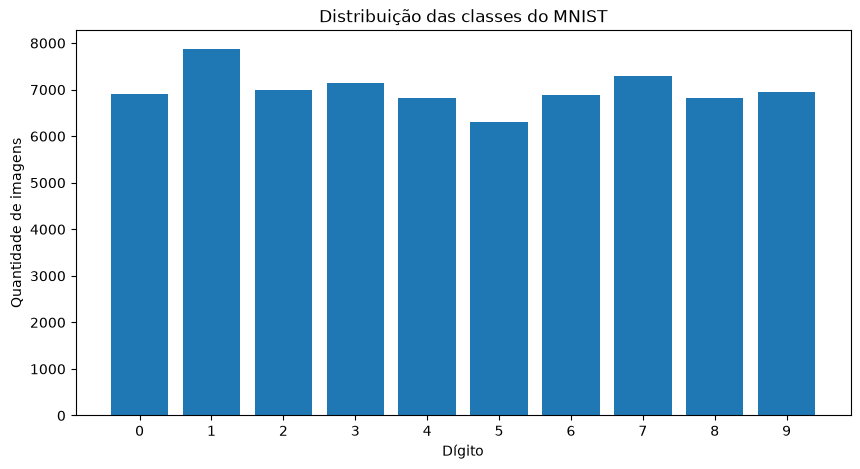

In [6]:
# Visualiza a distribuição das classes para facilitar a comparação entre os dígitos

plt.figure(figsize=(10, 5))  # Define o tamanho da figura
plt.bar(classes, contagens)  # Cria uma barra para a quantidade de imagens de cada dígito
plt.xticks(classes)  # Exibe no eixo X todos os dígitos de 0 a 9
plt.xlabel("Dígito")  # Identifica o eixo das classes
plt.ylabel("Quantidade de imagens")  # Identifica o eixo das frequências
plt.title("Distribuição das classes do MNIST")  # Define o título do gráfico
plt.show()  # Exibe a visualização

### Visualização das classes

Para verificar visualmente as características das imagens, será exibido um exemplo de cada classe do MNIST. A grade 2 × 5 permite representar os dez dígitos, de 0 a 9, juntamente com seus respectivos rótulos originais.

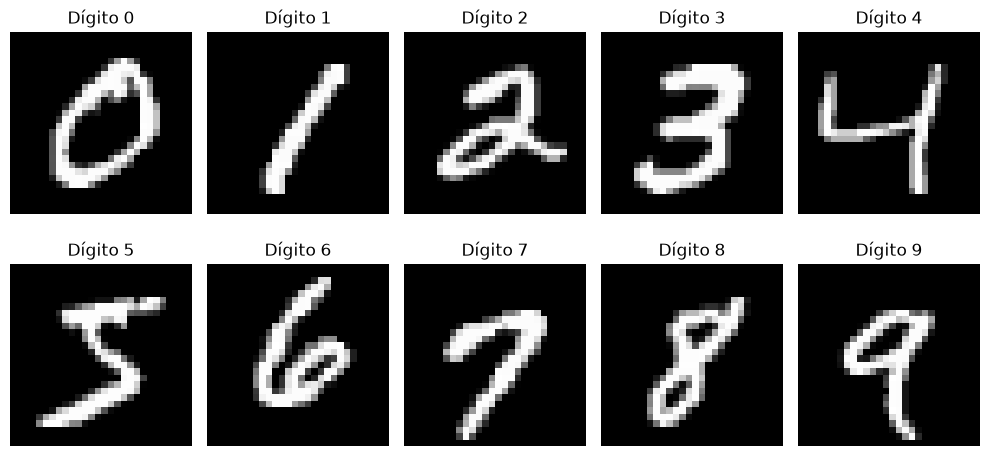

In [7]:
# Exibe um exemplo de cada dígito do MNIST em uma grade 2 x 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # Cria a grade com 2 linhas e 5 colunas

for digito in range(10):  # Percorre os dígitos de 0 a 9
    indice = np.where(y == digito)[0][0]  # Localiza a primeira imagem correspondente ao dígito atual
    eixo = axes.flat[digito]  # Seleciona a posição correspondente na grade

    eixo.imshow(X[indice], cmap="gray")  # Exibe a imagem em escala de cinza
    eixo.set_title(f"Dígito {y[indice]}")  # Mostra o rótulo original da imagem
    eixo.axis("off")  # Remove os eixos para destacar apenas a imagem

plt.tight_layout()  # Ajusta o espaçamento entre as imagens
plt.show()  # Exibe a grade completa

### Interpretação da estrutura dos dados

As imagens do MNIST possuem dimensão de **28 × 28 pixels** e são representadas em escala de cinza. Cada pixel apresenta intensidade entre **0 e 255**, em que valores próximos de 0 representam regiões mais escuras, valores próximos de 255 representam regiões mais claras e os valores intermediários correspondem aos diferentes tons de cinza.

Cada imagem é inicialmente representada como uma matriz bidimensional de 28 × 28 pixels. Para utilização em modelos clássicos de Machine Learning que esperam os dados em formato vetorial, essa matriz pode ser transformada em um vetor de **784 atributos (28 × 28 = 784)**, no qual cada pixel passa a representar uma feature.

A distribuição das classes mostrou quantidades semelhantes de exemplos para os dígitos de 0 a 9, sem evidência de desbalanceamento severo. Dessa forma, não há indicação, nesta análise inicial, da necessidade de técnicas específicas de balanceamento das classes.

A grade visual também confirma a presença das dez classes e evidencia variações naturais na escrita dos dígitos, característica que torna o MNIST adequado para avaliar e comparar modelos de classificação.

# Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados

Nesta fase, o conjunto MNIST será preparado para o treinamento dos modelos por meio de duas etapas principais:

- divisão estratificada em treino, validação e teste;
- normalização dos valores dos pixels para o intervalo [0, 1].

A divisão adotada será de 70% para treino, 10% para validação e 20% para teste, preservando a proporção das classes de 0 a 9 em cada subconjunto.

A normalização será realizada dividindo os valores dos pixels por 255.0, pois a escala original do MNIST é conhecida e varia de 0 a 255.

### Divisão estratificada dos dados

O dataset será dividido em **70% para treino, 10% para validação e 20% para teste**.

A divisão utiliza estratificação pelos rótulos (`stratify=y`) para preservar, em cada subconjunto, aproximadamente a mesma proporção dos dígitos de 0 a 9 existente no dataset original.

O conjunto de treino será utilizado para ajustar os modelos, o conjunto de validação para comparar configurações e hiperparâmetros durante o desenvolvimento, e o conjunto de teste será mantido independente para a avaliação final dos modelos.

In [8]:
# Divide o MNIST em conjuntos estratificados de treino, validação e teste

X_treino, X_validacao, X_teste, y_treino, y_validacao, y_teste = dividir_dados(X, y)  # Aplica a divisão 70% / 10% / 20%

tamanhos = {  # Organiza os resultados da divisão para facilitar a conferência
    "Treino": len(X_treino),
    "Validação": len(X_validacao),
    "Teste": len(X_teste)
}

tamanhos  # Exibe a quantidade de amostras destinada a cada conjunto

{'Treino': 49000, 'Validação': 7000, 'Teste': 14000}

In [9]:
# Compara a distribuição percentual das classes nos conjuntos original, treino, validação e teste

distribuicao_classes = {}  # Armazena as proporções das classes de cada conjunto para comparação

for nome, rotulos in {
    "Original": y,
    "Treino": y_treino,
    "Validação": y_validacao,
    "Teste": y_teste
}.items():
    classes, contagens = np.unique(rotulos, return_counts=True)  # Conta a quantidade de exemplos de cada dígito
    distribuicao_classes[nome] = np.round(contagens / len(rotulos) * 100, 2)  # Converte as contagens em percentuais

distribuicao_classes  # Exibe as proporções das classes nos quatro conjuntos

{'Original': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94]),
 'Treino': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94]),
 'Validação': array([ 9.86, 11.26,  9.99, 10.2 ,  9.74,  9.01,  9.83, 10.41,  9.76,
         9.94]),
 'Teste': array([ 9.86, 11.25,  9.99, 10.2 ,  9.75,  9.02,  9.82, 10.42,  9.75,
         9.94])}

### Normalização dos pixels

As imagens do MNIST possuem pixels representados originalmente por valores inteiros entre 0 e 255. Nesta etapa, esses valores serão convertidos para o intervalo **[0, 1]** por meio da divisão por 255.0.

A normalização mantém proporcionalmente as intensidades originais das imagens, mas coloca os atributos em uma escala numérica menor e padronizada. Esse procedimento é especialmente importante para modelos sensíveis à escala, como SVM e redes neurais, contribuindo para cálculos mais estáveis e para o processo de otimização.

Como o intervalo original dos pixels do MNIST é conhecido e fixo, foi utilizada a divisão direta por 255.0, sem necessidade de ajuste de um `MinMaxScaler`.

In [9]:
# Normaliza separadamente os conjuntos de treino, validação e teste para o intervalo [0, 1]

X_treino_norm = normalizar_pixels(X_treino)  # Normaliza as imagens utilizadas no treinamento
X_validacao_norm = normalizar_pixels(X_validacao)  # Normaliza as imagens utilizadas na validação
X_teste_norm = normalizar_pixels(X_teste)  # Normaliza as imagens reservadas para a avaliação final

intervalos_normalizados = {  # Organiza os valores mínimo e máximo para conferir o resultado da normalização
    "Treino": (X_treino_norm.min(), X_treino_norm.max()),
    "Validação": (X_validacao_norm.min(), X_validacao_norm.max()),
    "Teste": (X_teste_norm.min(), X_teste_norm.max())
}

intervalos_normalizados  # Exibe os intervalos obtidos após a normalização

{'Treino': (np.float32(0.0), np.float32(1.0)),
 'Validação': (np.float32(0.0), np.float32(1.0)),
 'Teste': (np.float32(0.0), np.float32(1.0))}

### Interpretação do pré-processamento

A divisão estratificada preservou proporções muito semelhantes das classes de 0 a 9 nos conjuntos de treino, validação e teste, mantendo a representatividade do dataset após a separação.

A divisão adotada resultou em 49.000 amostras para treino, 7.000 para validação e 14.000 para teste, correspondendo respectivamente a 70%, 10% e 20% do conjunto completo.

A normalização transformou os pixels da escala original de 0 a 255 para o intervalo [0, 1], sem alterar as dimensões das imagens. Essa transformação favorece a estabilidade numérica e a convergência de modelos sensíveis à escala, além de beneficiar métodos que utilizam distâncias, margens ou medidas de similaridade.

Como a escala original do MNIST é conhecida e fixa, a divisão direta por 255.0 foi suficiente, dispensando o ajuste de um MinMaxScaler.

# Fase 3 — Implementação e Treinamento dos Modelos

Nesta fase serão implementados e treinados três modelos de classificação com abordagens distintas: **Random Forest, Support Vector Machine (SVM) e Multilayer Perceptron (MLP)**.

A escolha desses modelos permite comparar diferentes estratégias de aprendizado: o Random Forest utiliza um conjunto de árvores de decisão, o SVM busca fronteiras de decisão com máxima margem e a MLP utiliza uma rede neural multicamadas capaz de aprender relações não lineares entre os atributos.

Para os três modelos serão avaliados hiperparâmetros específicos utilizando o conjunto de validação. O conjunto de teste permanecerá isolado nesta etapa e será utilizado posteriormente para a avaliação final, evitando que informações do teste influenciem a escolha dos modelos.

### Vetorização das imagens

Os modelos utilizados nesta etapa recebem cada amostra como um vetor de atributos. Como as imagens do MNIST estão armazenadas no formato 28 × 28, cada imagem será reorganizada em um vetor com 784 atributos, correspondentes aos seus pixels.

Essa transformação altera apenas o formato dos dados, preservando os valores e a quantidade de amostras.

In [10]:
# Transforma as imagens 28 x 28 em vetores com 784 atributos

X_treino_modelo = achatar_imagens(X_treino_norm)  # 49.000 imagens de treino
X_validacao_modelo = achatar_imagens(X_validacao_norm)  # 7.000 imagens de validação

formatos_modelos = {
    "Treino": X_treino_modelo.shape,
    "Validação": X_validacao_modelo.shape
}

formatos_modelos

{'Treino': (49000, 784), 'Validação': (7000, 784)}

### Modelo 1 — Random Forest

O Random Forest combina várias árvores de decisão e utiliza a votação entre elas para realizar a classificação.

Nesta etapa serão comparadas duas configurações variando os hiperparâmetros `n_estimators` e `max_depth`.

- `n_estimators` controla a quantidade de árvores construídas.
- `max_depth` limita a profundidade máxima das árvores, ajudando a controlar a complexidade do modelo.

A comparação será realizada no conjunto de validação, mantendo o conjunto de teste reservado para a avaliação final.

In [11]:
# Configuração 1 do Random Forest: 100 árvores sem limite explícito de profundidade

rf_1, tempo_rf_1 = treinar_random_forest(
    X_treino_modelo,
    y_treino,
    n_estimators=100,
    max_depth=None
)

acuracia_rf_1 = avaliar_modelo(
    rf_1,
    X_validacao_modelo,
    y_validacao
)

resultado_rf_1 = {
    "n_estimators": 100,
    "max_depth": None,
    "acurácia_validação": round(acuracia_rf_1, 4),
    "tempo_treinamento_s": round(tempo_rf_1, 2)
}

resultado_rf_1

{'n_estimators': 100,
 'max_depth': None,
 'acurácia_validação': 0.9649,
 'tempo_treinamento_s': 8.06}

In [12]:
# Configuração 2 do Random Forest: 200 árvores e profundidade máxima igual a 20

rf_2, tempo_rf_2 = treinar_random_forest(
    X_treino_modelo,
    y_treino,
    n_estimators=200,
    max_depth=20
)

acuracia_rf_2 = avaliar_modelo(
    rf_2,
    X_validacao_modelo,
    y_validacao
)

resultado_rf_2 = {
    "n_estimators": 200,
    "max_depth": 20,
    "acurácia_validação": round(acuracia_rf_2, 4),
    "tempo_treinamento_s": round(tempo_rf_2, 2)
}

resultado_rf_2

{'n_estimators': 200,
 'max_depth': 20,
 'acurácia_validação': 0.9661,
 'tempo_treinamento_s': 16.92}

### Interpretação do Random Forest

Foram comparadas duas configurações do Random Forest por meio dos hiperparâmetros `n_estimators` e `max_depth`.

A primeira configuração, com 100 árvores e sem limite explícito de profundidade, atingiu acurácia de validação de **96,49%**, com tempo de treinamento de **8,75 segundos**.

A segunda configuração, com 200 árvores e profundidade máxima igual a 20, atingiu acurácia de **96,61%**, com tempo de treinamento de **16,76 segundos**.

Embora a segunda configuração tenha apresentado apenas um pequeno ganho de acurácia, seu desempenho foi superior no conjunto de validação e, por esse critério, foi selecionada para representar o Random Forest na avaliação final. O aumento do número de árvores também elevou o custo computacional, praticamente dobrando o tempo de treinamento, evidenciando o compromisso entre desempenho preditivo e custo computacional.

### Modelo 2 — Support Vector Machine (SVM)

O Support Vector Machine (SVM) realiza a classificação buscando fronteiras de decisão que maximizem a margem entre as classes.

Serão comparadas duas configurações por meio dos hiperparâmetros `C` e `kernel`. O parâmetro `C` controla a penalização aplicada aos erros de classificação, enquanto o `kernel` determina a forma da fronteira de decisão.

A primeira configuração utiliza kernel linear e `C=1.0`. A segunda utiliza o kernel RBF e `C=10.0`, permitindo comparar uma fronteira linear com uma não linear.

Devido ao maior custo computacional do SVM, especialmente com o kernel RBF, foram escolhidas configurações pontuais em vez de uma busca exaustiva de hiperparâmetros.

In [13]:
# Configuração 1 do SVM: penalização C igual a 1.0 e kernel linear

svm_1, tempo_svm_1 = treinar_svm(
    X_treino_modelo,
    y_treino,
    C=1.0,
    kernel="linear"
)

acuracia_svm_1 = avaliar_modelo(
    svm_1,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_1 = {
    "C": 1.0,
    "kernel": "linear",
    "acurácia_validação": round(acuracia_svm_1, 4),
    "tempo_treinamento_s": round(tempo_svm_1, 2)
}

resultado_svm_1

{'C': 1.0,
 'kernel': 'linear',
 'acurácia_validação': 0.9334,
 'tempo_treinamento_s': 145.93}

In [14]:
del svm_1  # Remove da memória o modelo SVM utilizado na primeira comparação

import gc  # Importa o coletor de memória do Python
gc.collect()  # Solicita a liberação de objetos que não são mais necessários

48

In [15]:
# Seleciona uma amostra estratificada do conjunto de treino para reduzir o custo computacional do ajuste do SVM

X_treino_svm, _, y_treino_svm, _ = train_test_split(
    X_treino_modelo,
    y_treino,
    train_size=20000,
    stratify=y_treino,
    random_state=42
)

X_treino_svm.shape, y_treino_svm.shape

((20000, 784), (20000,))

In [16]:
# SVM 1 em amostra estratificada: C=1.0 e kernel linear

svm_1_amostra, tempo_svm_1_amostra = treinar_svm(
    X_treino_svm,
    y_treino_svm,
    C=1.0,
    kernel="linear"
)

acuracia_svm_1_amostra = avaliar_modelo(
    svm_1_amostra,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_1_amostra = {
    "C": 1.0,
    "kernel": "linear",
    "acurácia_validação": round(acuracia_svm_1_amostra, 4),
    "tempo_treinamento_s": round(tempo_svm_1_amostra, 2)
}

resultado_svm_1_amostra

{'C': 1.0,
 'kernel': 'linear',
 'acurácia_validação': 0.9219,
 'tempo_treinamento_s': 24.08}

In [17]:
# SVM 2 em amostra estratificada: C=10.0 e kernel RBF

svm_2_amostra, tempo_svm_2_amostra = treinar_svm(
    X_treino_svm,
    y_treino_svm,
    C=10.0,
    kernel="rbf"
)

acuracia_svm_2_amostra = avaliar_modelo(
    svm_2_amostra,
    X_validacao_modelo,
    y_validacao
)

resultado_svm_2_amostra = {
    "C": 10.0,
    "kernel": "rbf",
    "acurácia_validação": round(acuracia_svm_2_amostra, 4),
    "tempo_treinamento_s": round(tempo_svm_2_amostra, 2)
}

resultado_svm_2_amostra

{'C': 10.0,
 'kernel': 'rbf',
 'acurácia_validação': 0.9721,
 'tempo_treinamento_s': 32.39}

### Interpretação do SVM

Devido ao elevado custo computacional observado inicialmente com o SVM utilizando todo o conjunto de treinamento, o ajuste dos hiperparâmetros foi realizado sobre uma amostra estratificada de 20.000 imagens, preservando a distribuição das classes. O conjunto de validação permaneceu inalterado e o conjunto de teste não foi utilizado nesta etapa.

Foram comparadas duas configurações utilizando os hiperparâmetros `C` e `kernel`. A configuração com `C=1.0` e kernel linear alcançou acurácia de validação de **92,19%**, com tempo de treinamento de **27,52 segundos**. A configuração com `C=10.0` e kernel RBF alcançou **97,21%**, com tempo de **32,14 segundos**.

O kernel RBF apresentou ganho de aproximadamente **5,02 pontos percentuais** de acurácia com aumento relativamente pequeno no tempo de treinamento. Por esse motivo, a configuração com `C=10.0` e kernel RBF foi selecionada.

A utilização da amostra estratificada durante o ajuste também permitiu controlar o consumo de recursos computacionais, mantendo a representatividade das classes e evitando o uso do conjunto de teste durante a seleção do modelo.

### Modelo 3 — Multilayer Perceptron (MLP)

A Multilayer Perceptron (MLP) é uma rede neural composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Durante o treinamento, os pesos das conexões são ajustados iterativamente para reduzir o erro de classificação.

Nesta etapa serão comparadas duas configurações por meio dos hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`. O primeiro determina a arquitetura das camadas ocultas da rede, enquanto o segundo controla a magnitude inicial das atualizações realizadas durante o processo de aprendizagem.

Como os pixels foram previamente normalizados para o intervalo [0, 1], os dados encontram-se em uma escala adequada para o processo de otimização utilizado pela rede neural.

In [18]:
# Configuração 1 da MLP: uma camada oculta com 100 neurônios e taxa de aprendizado 0.001

mlp_1, tempo_mlp_1 = treinar_mlp(
    X_treino_modelo,
    y_treino,
    hidden_layer_sizes=(100,),
    learning_rate_init=0.001
)

acuracia_mlp_1 = avaliar_modelo(
    mlp_1,
    X_validacao_modelo,
    y_validacao
)

resultado_mlp_1 = {
    "hidden_layer_sizes": (100,),
    "learning_rate_init": 0.001,
    "acurácia_validação": round(acuracia_mlp_1, 4),
    "tempo_treinamento_s": round(tempo_mlp_1, 2)
}

resultado_mlp_1

c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layer_sizes': (100,),
 'learning_rate_init': 0.001,
 'acurácia_validação': 0.9756,
 'tempo_treinamento_s': 17.91}

In [21]:
# Configuração 2 da MLP: duas camadas ocultas com 128 e 64 neurônios e taxa de aprendizado 0.0005

mlp_2, tempo_mlp_2 = treinar_mlp(
    X_treino_modelo,
    y_treino,
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.0005
)

acuracia_mlp_2 = avaliar_modelo(
    mlp_2,
    X_validacao_modelo,
    y_validacao
)

resultado_mlp_2 = {
    "hidden_layer_sizes": (128, 64),
    "learning_rate_init": 0.0005,
    "acurácia_validação": round(acuracia_mlp_2, 4),
    "tempo_treinamento_s": round(tempo_mlp_2, 2)
}

resultado_mlp_2

c:\Users\crisj\OneDrive\Área de Trabalho\SCTECH\Desenvolvimento de IA para Análise Preditiva T2\IA\MiniProjetos\mnist-model-benchmark\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


{'hidden_layer_sizes': (128, 64),
 'learning_rate_init': 0.0005,
 'acurácia_validação': 0.9759,
 'tempo_treinamento_s': 27.35}

### Interpretação da MLP

Foram comparadas duas configurações da rede neural MLP, variando os hiperparâmetros `hidden_layer_sizes` e `learning_rate_init`.

A primeira configuração, com uma camada oculta de 100 neurônios e taxa de aprendizado de 0,001, atingiu acurácia de validação de **97,56%**, com tempo de treinamento de **17,91 segundos**.

A segunda configuração, composta por duas camadas ocultas de 128 e 64 neurônios e taxa de aprendizado de 0,0005, atingiu **97,59%**, com tempo de treinamento de **26,26 segundos**.

A segunda configuração apresentou a maior acurácia e foi selecionada para representar a MLP. Entretanto, o ganho de apenas 0,03 ponto percentual ocorreu com aumento relevante no tempo de treinamento, demonstrando que uma arquitetura mais complexa não produziu, neste experimento, melhoria proporcional no desempenho.

Ambas as configurações atingiram o limite de 30 iterações antes do critério interno de convergência do `MLPClassifier`, informação que deve ser considerada na interpretação dos resultados.